In [1]:
import sys
lib_path = [r'C:\Users\ikahbasi\OneDrive\Applications\GitHub\SeisRoutine',
            r'C:\Users\ikahb\OneDrive\Applications\GitHub\SeisRoutine',
            '/home/ikahbasi/Works/SeisRoutine']
for path in lib_path:
    sys.path.append(path)
##########################################################################
import SeisRoutine.catalog as src
import SeisRoutine.waveform as srw
import SeisRoutine.config as srconf
import SeisRoutine.statistics as srs
##########################################################################
import myfuncs as mf

In [ ]:
import seisbench.generate as sbg
import seisbench.models as sbm
import torch
from tqdm import tqdm
from scipy import signal
import os
import seisbench.data as sbd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label
import pandas as pd
import logging
from obspy import UTCDateTime as utc


# Classes and Functions

In [3]:
class Tapering:
    def __init__(self, alpha=0.3, key='X'):
        self.alpha = alpha  # Tapering Coefficient
        if isinstance(key, str):
            self.key = (key, key)
        else:
            self.key = key

    def __call__(self, state_dict):
        x, metadata = state_dict[self.key[0]]
        taper = signal.windows.tukey(x.shape[-1], self.alpha)
        x = x * taper
        state_dict[self.key[1]] = (x, metadata)

In [4]:
def find_peaks(data, treshold):
    mask = data > treshold
    labeled, num_features = label(mask)
    peaks = []
    for i in range(1, num_features + 1):
        segment_indices = np.where(labeled == i)[0]
        segment_values = data[segment_indices]
        max_index = np.argmax(segment_values)
        max_index_in_segment = segment_indices[max_index]
        peaks.append(max_index_in_segment)
    return np.array(peaks)

# Loading DataSets

In [5]:
init_cfg = srconf.load_config('0-init-cfg.yml')
cfg_path = os.path.join(init_cfg.target_config_filepath,
                        init_cfg.target_config_filename)
cfg = srconf.load_config(cfg_path)

In [6]:
srconf.configure_logging(level=cfg.log.level,
                         log_format=cfg.log.format,
                         mode=cfg.log.mode, colored_console=True,
                         filepath=cfg.dataset.path,
                         filename_prefix=cfg.log.filename_prefix,
                         filename=cfg.log.filename)

Logging Starts in:
/media/ikahbasi/Local Disk ikahbasi 4T1/DataSets-Local/AutoLabeling_on_Merged_datasets_2026-01-05_18-00-07.log


In [7]:
mf.resources.Check_CUDA_availability()
txt = mf.resources.get_cpu_info()
logging.info(txt)

2026-01-05 18:00:12 - INFO - CUDA available: True
2026-01-05 18:00:12 - INFO - CUDA device count: 1
2026-01-05 18:00:12 - INFO - Current device index: 0
2026-01-05 18:00:12 - INFO - Current device name: NVIDIA GeForce GTX 1650
2026-01-05 18:00:12 - INFO - 
=== Device Properties ===
2026-01-05 18:00:12 - INFO - Name: NVIDIA GeForce GTX 1650
2026-01-05 18:00:12 - INFO - Total memory (GB): 3.63
2026-01-05 18:00:12 - INFO - Multiprocessors: 14
2026-01-05 18:00:12 - INFO - Compute capability: 7.5
2026-01-05 18:00:12 - INFO - Max threads per block: N/A
2026-01-05 18:00:12 - INFO - Max threads per multiprocessor: 1024
2026-01-05 18:00:12 - INFO - Shared memory per block (bytes): 49152
2026-01-05 18:00:12 - INFO - Warp size: 32
2026-01-05 18:00:13 - INFO - Clock rate (kHz): N/A
2026-01-05 18:00:13 - INFO - 
=== Memory Usage ===
2026-01-05 18:00:13 - INFO - Allocated (GB): 0.000
2026-01-05 18:00:13 - INFO - Reserved (GB): 0.000
2026-01-05 18:00:13 - INFO - 
=== nvidia-smi Output ===
2026-01-05 

In [8]:
dataset = sbd.WaveformDataset(
    path=os.path.join(cfg.dataset.path, cfg.dataset.fname),
    sampling_rate=cfg.training.dataset.sampling_rate,
    component_order=cfg.training.dataset.component_order,
          )

In [39]:
sps = 100
left_pad = 15 * sps
augmentations = [
    Tapering(),
    # sbg.Filter(N=4,
    #            Wn=[0.5],
    #            btype='highpass',
    #            forward_backward=True,
    #            ),
    sbg.Normalize(
        demean_axis=-1,
        amp_norm_axis=-1,
        amp_norm_type="peak"),
    sbg.FixedWindow(
        p0=-left_pad,
        windowlen=1*60*sps,
        strategy="pad",
        key='X'),
    sbg.ChangeDtype(np.float32),
]
generator = sbg.GenericGenerator(dataset)
generator.add_augmentations(augmentations)

In [25]:
from torch.utils.data import DataLoader
from seisbench.util import worker_seeding

In [11]:
batch_size = 1024 * 5
num_workers = 0  # The number of threads used for loading data
dataloader = DataLoader(
    generator,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
)


# Loading Auto-Pickers

In [12]:
dl_pickers = {
    #'PhaseNet_stead': sbm.PhaseNet.from_pretrained("stead"),
    'PhaseNet_original': sbm.PhaseNet.from_pretrained("original"),
    #   'PhaseNet_scedc': sbm.PhaseNet.from_pretrained("scedc"),
    #   'PhaseNet_instance': sbm.PhaseNet.from_pretrained("instance"),
    ############################################################################
    # 'EQTransformer_stead': sbm.EQTransformer.from_pretrained("stead"),
      'EQTransformer_original': sbm.EQTransformer.from_pretrained("original"),
    #   'EQTransformer_scedc': sbm.EQTransformer.from_pretrained("scedc"),
    #   'EQTransformer_instance': sbm.EQTransformer.from_pretrained("instance"),
    ############################################################################
    #   sbm.GPD.from_pretrained("stead"),
    # 'GPD_original': sbm.GPD.from_pretrained("original"),
    #   'GPD_scedc': sbm.GPD.from_pretrained("scedc"),
    #   'GPD_instance': sbm.GPD.from_pretrained("instance"),
}

if torch.cuda.is_available():
    for key, dl_picker in dl_pickers.items():
        dl_picker.cuda();
        logging.info(f"{key} Running on GPU")
        logging.info(dl_picker._annotate_args.get("*_threshold"))
else:
    logging.info("Running on CPU")

2026-01-05 18:00:32 - INFO - PhaseNet_original Running on GPU
2026-01-05 18:00:32 - INFO - ('Detection threshold for the provided phase', 0.3)
2026-01-05 18:00:32 - INFO - EQTransformer_original Running on GPU
2026-01-05 18:00:32 - INFO - ('Detection threshold for the provided phase', 0.1)


# Run

In [13]:
metadata = dataset.metadata.copy()

In [14]:
# lst = []
# for ii in tqdm(range(len(metadata))):
#     data = generator[ii]
#     data_X = data['X']
#     lst.append(data_X.shape)
# for index, el in enumerate(lst):
#     if el != (3, 3001):
#         print(f'{el=}\t{index=}\t{lst.count(el)=}')

In [15]:
# for batch_id, batch in enumerate(dataloader):
#     print(batch_id)
#     break

In [40]:
# x = torch.tensor(batch['X']).to(dl_picker.device)#.unsqueeze(0)
# annotated = dl_picker.annotate_batch_pre(x, {})

In [18]:
# annotated

In [19]:
# plt.plot(annotated[2][2].cpu().T)

In [20]:
# p_peaks = find_peaks(annotated[1], treshold=treshold)

In [21]:
# annotated[0]

In [54]:
# for key, dl_picker in dl_pickers.items():
#     treshold = dl_picker._annotate_args.get("*_threshold")[1]
#     for ii in tqdm(range(len(metadata))):
#         data = generator[ii]
#         data_X0 = data['X']
#         if data_X0.shape != (3, 3001):
#             continue
#         data_X = torch.tensor(data_X0, device=dl_picker.device).unsqueeze(0)
#         # logging.info(f'{ii}, {key}')
#         with torch.no_grad():
#             pred = dl_picker(data_X)
#             pred = pred.cpu().detach().numpy().squeeze()
#         p_peaks = find_peaks(pred[1], treshold=treshold)
#         s_peaks = find_peaks(pred[2], treshold=treshold)
#         # print(p_peaks, s_peaks)
#         metadata.at[ii, f'trace_P_{key}-AutoPik'] = p_peaks
#         metadata.at[ii, f'trace_S_{key}-AutoPik'] = s_peaks
# path = os.path.join(cfg.dataset.path, 'metadata-with-AutoPicks.pkl')
# metadata.to_pickle(path)

In [22]:
import torch
import numpy as np

def standardize_output(pred, dl_picker):
    """
    pred: خروجی خام مدل
    model_name: 'phasenet' یا 'eqtransformer'
    خروجی: np.ndarray با شکل [3, N] (Noise, P, S)
    """
    if dl_picker.name == "PhaseNet":
        # خروجی خودش همین شکله
        if isinstance(pred, torch.Tensor):
            pred = pred.detach().cpu().numpy().squeeze()
        return pred  # [3, N]

    elif dl_picker.name == "EQTransformer":
        # خروجی tuple از سه tensor
        arrs = [x.detach().cpu().numpy().squeeze() for x in pred]
        return np.vstack(arrs)  # [3, N]

    else:
        raise ValueError(f"Unknown model: {dl_picker.name}")


In [ ]:
for key, model in dl_pickers.items():
    for phase in ['P', 'S']:
        metadata[f'trace_{phase}_{key}-AutoPik'] = None  # or object
        metadata = metadata.astype({f'trace_{phase}_{key}-AutoPik': 'object'}, copy=False)

for ii in tqdm(range(len(metadata))):
    data = generator[ii]
    data_X0 = data['X']
    # if data_X0.shape != (3, 3001):
    #     continue
    
    # plt.plot(data_X.T); plt.show()
    for key, dl_picker in dl_pickers.items():
        data_X = torch.tensor(data_X0, device=dl_picker.device).unsqueeze(0)
        # logging.info(f'{ii}, {key}')
        with torch.no_grad():
            pred = dl_picker(data_X)
            # pred = pred.cpu().detach().numpy().squeeze()
        pred = standardize_output(pred, dl_picker)
        treshold = dl_picker._annotate_args.get("*_threshold")[1]
        p_peaks = find_peaks(pred[1], treshold=treshold)
        s_peaks = find_peaks(pred[2], treshold=treshold)
        # print(p_peaks, s_peaks)
        metadata.at[ii, f'trace_P_{key}-AutoPik'] = p_peaks - left_pad
        metadata.at[ii, f'trace_S_{key}-AutoPik'] = s_peaks - left_pad
        #
        # plt.plot(pred.T[:, 1:]); plt.legend([_ for _ in 'PS'])
        # plt.vlines(p_peaks, ymin=0, ymax=1, colors='red')
        # plt.vlines(s_peaks, ymin=0, ymax=1, colors='blue')
        # results[key] = pred
    # plt.show()
now = utc().strftime('%Y.%m.%d-%H.%M.%S')
path = os.path.join(cfg.dataset.path, cfg.dataset.fname, f'metadata-with-AutoPicks-{now}.pkl')
msg = f'Result Saved at: {path}'
logging.info(msg)
metadata.to_pickle(path)

100%|██████████| 81014/81014 [3:23:48<00:00,  6.63it/s]  
2026-01-05 23:05:43 - INFO - Result Saved at: /media/ikahbasi/Local Disk ikahbasi 4T1/DataSets-Local/metadata-with-AutoPicks.pkl


In [75]:
def filter_min_residual(row, key):
    el = row[key]
    if isinstance(el, np.ndarray):
        if all(np.isnan(el)):
            output = np.nan
        else:
            output = el[np.argmin(np.abs(el))]
    else:
        if np.isnan(el):
            output = np.nan
        if isinstance(el, (int, float, complex)):
            output = el
        else:
            print(el, type(el))
    return output

In [82]:
metadata_res = metadata.copy()
metadata[[key for key in metadata.keys() if key.startswith('trace_S')]]

metadata_res['trace_P_PhaseNet_original-AutoPik'] -= metadata_res['trace_Pg_arrival_sample']
metadata_res['trace_P_EQTransformer_original-AutoPik'] -= metadata_res['trace_Pg_arrival_sample']

metadata_res['trace_S_PhaseNet_original-AutoPik'] -= metadata_res['trace_Sg_arrival_sample']
metadata_res['trace_S_EQTransformer_original-AutoPik'] -= metadata_res['trace_Sg_arrival_sample']

keys = [key for key in metadata.keys() if key.endswith('-AutoPik')]
for key in keys:
    metadata_res[key] = metadata_res.apply(lambda x: filter_min_residual(row=x, key=key), axis=1)

In [77]:
import SeisRoutine.plot as srp

In [80]:
arr_error.values

array([  nan, 1930.,   nan, ..., -742.,   nan,  592.])

ValueError: cannot convert float NaN to integer

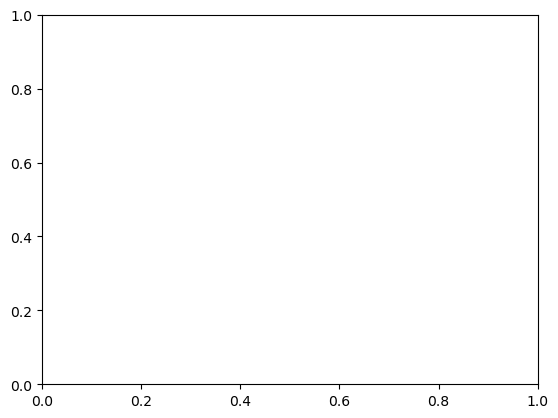

In [ ]:
for key in keys:
    arr_error = metadata_res[key].values
    srp.histogram(arr_error,
                orientation='vertical',
                figsize=(6, 4), title=f'{key}  {phase}', around_zero=False, step=0.5,
                xlim=[-5, 5],
                xlabel='Residual [$t_M - t_C$]', ylabel='Count',
                save=True, savefile=f'{key}{phase}_hist.png')
    srp.density_hist(x=arr_dist, y=arr_error,
                    xstep=5, ystep=0.25,
                    ylim=[-4, 4],
                    figsize=(10, 4), title=f'{key}  {phase}',
                    xlabel='Distance [km]', ylabel='Residual [$t_M - t_C$]',
                    save=True, savefile=f'{key}{phase}_dist.png')

In [52]:
# pred = dl_picker(data_X)
# pred = pred.detach()
# for index, p in enumerate(pred):
#     plt.plot(p.cpu().T, label=index)
# plt.legend()

In [53]:
# for index, p in enumerate(pred):
#     plt.plot(p.cpu().T, label=index)
# plt.legend()